# 3. Descriptive Statistics
- Health metrics
- Sleep durations
- Personal exposure (PM, CO2, temperature, rel humidity)
- Purifier's raw and corrected temperature and rel humidity

In [21]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/plot_helpers.R")
source("../util/descriptive_stats_helper.R")

ALL_SAMPLES_RAW_DATA <- read_rds("../R-table/ALL_SAMPLES_RAW_DATA.rds") |> 
    filter(
        sample_type_id %in% HEALTH_METRICS
    ) |> 
    rename(type_id = sample_type_id)

HEALTH_METRIC_WITH_EXPOSURE_DFS <- read_rds("../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")

HEALTH_METRIC_WITH_EXPOSURE <- bind_rows(HEALTH_METRIC_WITH_EXPOSURE_DFS) |> 
    filter(
        sample_type_id %in% HEALTH_METRICS
    ) |> 
    rename(type_id = location_type) |>
    select(pseudonym, type_id, sample_type_id, start_date, period_id, treatment, value)
    
SLEEP_RAW_DATA_BY_DATE <- read_rds("../R-table/SLEEP_RAW_DATA_BY_DATE.rds") |> 
    filter(
        !sample_type_id %in% IN_BED
    ) |> 
    rename(type_id = sample_type_id)

PERSONAL_EXPOSURE <- read_rds("../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED.rds") |>
    select(-pm1, -pm10) |> 
    rename(type_id = location_type)

ALL_LOCATION_DATA <- read_rds("../R-table/ALL_LOCATION_DATA.rds") |> 
    rename(type_id = location_type)

PURIFIER_AND_PARTICIPANT_DATA <- read_rds("../R-table/PURIFIER_AND_PARTICIPANT_DATA.rds")


In [22]:
AGGREGATION_PERIOD = "100 years" # bootstrap to average over entire dataset

## 3.1. Summarize each metric for each participant

In [23]:
health_metric_summary_each_participant <- process_and_summarize_each_metric_each_participant(
    data = HEALTH_METRIC_WITH_EXPOSURE |> filter(sample_type_id != RHR), # RHR is across all location so it will be added below
    group_by_cols = c("pseudonym", "treatment", "type_id", "sample_type_id")
)

# Add a virtual flag for all location 
HEALTH_METRIC_WITH_EXPOSURE_ALL_LOCATION <- HEALTH_METRIC_WITH_EXPOSURE |>
    mutate(
        type_id = "all"
    )
health_metric_summary_each_participant_all_location <- process_and_summarize_each_metric_each_participant(
    data = HEALTH_METRIC_WITH_EXPOSURE_ALL_LOCATION,
    group_by_cols = c("pseudonym", "treatment", "type_id", "sample_type_id")
)

# Then join back to the original summary
health_metric_summary_each_participant <- bind_rows(
        health_metric_summary_each_participant,
        health_metric_summary_each_participant_all_location
    ) |>
  pivot_wider(
    names_from = sample_type_id,
    values_from = value
  )

In [24]:
sleep_stage_summary_each_participant  <- process_and_summarize_each_metric_each_participant(
    data = SLEEP_RAW_DATA_BY_DATE,
    group_by_cols = c("pseudonym", "treatment", "type_id")
)

In [25]:
exposure_summary_each_participant <- process_and_summarize_each_metric_each_participant(
    data = PERSONAL_EXPOSURE,
    group_by_cols = c("pseudonym", "treatment", "type_id")
    )

exposure_summary_each_participant <- exposure_summary_each_participant |>
  mutate(co2 = if_else(type_id == "outdoors", NA_real_, co2))

# Add a virtual flag for all location 
PERSONAL_EXPOSURE_ALL_LOCATION <- PERSONAL_EXPOSURE |>
    select(-co2) |>  # exclude 'co2'
    mutate(
        type_id = "all"
    )
exposure_summary_each_participant_all_location <- process_and_summarize_each_metric_each_participant(
    data = PERSONAL_EXPOSURE_ALL_LOCATION,
    group_by_cols = c("pseudonym", "treatment", "type_id")
    )

# Then join back to the original summary
exposure_summary_each_participant <- bind_rows(exposure_summary_each_participant, exposure_summary_each_participant_all_location)

In [26]:
# Pre-process
TEMP_HUMID_RAW_VS_CORRECTED <- PURIFIER_AND_PARTICIPANT_DATA |>
    select(pseudonym, treatment, start_date, temperature, temperature_raw, humidity, humidity_raw) |>
    transmute(
        across(-c(temperature, temperature_raw, humidity, humidity_raw)),
        type_id = "corrected",
        temperature = temperature,
        humidity = humidity
    ) |>
    bind_rows(
        PURIFIER_AND_PARTICIPANT_DATA |>
        select(pseudonym, treatment, start_date, temperature, temperature_raw, humidity, humidity_raw) |>
        transmute(
            across(-c(temperature, temperature_raw, humidity, humidity_raw)),
            type_id = "raw",
            temperature = temperature_raw,
            humidity = humidity_raw
        )
    )

temp_humid_summary_each_participant  <- process_and_summarize_each_metric_each_participant(
    data = TEMP_HUMID_RAW_VS_CORRECTED,
    group_by_cols = c("pseudonym", "treatment", "type_id"),
    should_remove_travel = FALSE
)

## 3.2. Normality Testing

### 3.2.1. Calculate pair-wise difference for each metric for each participant

In [49]:
health_metric_treatment_diff <- treatment_diff(
    summary_per_participant = health_metric_summary_each_participant,
    summarise_by = HEALTH_METRICS
)
head(health_metric_treatment_diff, n = 5)

pseudonym,type_id,heart-rate_treatment1,resting-heart-rate_treatment1,hrv_treatment1,respiratory-rate_treatment1,oxygen-saturation_treatment1,heart-rate_treatment2,resting-heart-rate_treatment2,hrv_treatment2,respiratory-rate_treatment2,oxygen-saturation_treatment2,heart-rate_diff,resting-heart-rate_diff,hrv_diff,respiratory-rate_diff,oxygen-saturation_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,all,64.96174,52.00000,43.53060,13.31839,96.38806,65.13415,54.41667,42.54475,12.92643,95.95098,0.1724125,2.416667,-0.985849,-0.3919517,-0.4370793
apple3,home,57.15986,NaN,44.54763,13.32200,96.29268,50.76779,NaN,42.79642,12.87867,95.46067,-6.3920644,NaN,-1.751212,-0.4433288,-0.8320088
apple3,indoors,71.06006,NaN,42.63894,13.00000,98.00000,77.29868,NaN,43.73228,13.86207,97.75000,6.2386199,NaN,1.093346,0.8620690,-0.2500000
apple3,outdoors,83.12495,NaN,38.63297,NaN,95.00000,80.54672,NaN,35.68388,NaN,98.28571,-2.5782314,NaN,-2.949096,NaN,3.2857143
banana8,all,72.76868,62.78571,80.72074,16.26794,97.39655,71.70565,64.62500,78.83821,16.42798,97.42735,-1.0630301,1.839286,-1.882531,0.1600423,0.0307987


In [51]:
sleep_stage_treatment_diff <- treatment_diff(
    summary_per_participant = sleep_stage_summary_each_participant,
    summarise_by = "value"
)
head(sleep_stage_treatment_diff, n = 5)

pseudonym,type_id,treatment1,treatment2,treatment2_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
apple3,alseep_all,6.47916667,6.02333333,-0.45583333
apple3,asleep_core,3.77250000,3.55833333,-0.21416667
apple3,asleep_deep,0.91666667,0.88750000,-0.02916667
apple3,asleep_rem,1.73560606,1.70312500,-0.03248106
apple3,awake,0.07604167,0.08611111,0.01006944


In [52]:
exposure_treatment_diff <- treatment_diff(
    summary_per_participant = exposure_summary_each_participant,
    summarise_by = SENSOR_METRICS
)
head(exposure_treatment_diff, n = 5)

pseudonym,type_id,pm25_treatment1,co2_treatment1,temperature_treatment1,humidity_treatment1,pm25_treatment2,co2_treatment2,temperature_treatment2,humidity_treatment2,pm25_diff,co2_diff,temperature_diff,humidity_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,all,11.226599,NaN,22.80671,56.16523,11.440612,NaN,23.61579,56.18050,0.2140126,NaN,0.80907783,0.0152750
apple3,home,10.537770,553.6103,23.31562,53.91070,6.243724,500.0445,24.61386,53.79719,-4.2940464,-53.56577,1.29823696,-0.1135170
apple3,indoors,8.158788,518.7217,21.70930,57.68607,10.834613,582.7814,21.40441,58.03871,2.6758248,64.05965,-0.30489045,0.3526426
apple3,outdoors,19.803067,NaN,22.67025,68.61584,34.165517,NaN,25.83813,59.51582,14.3624495,NaN,3.16787554,-9.1000157
banana8,all,5.944655,NaN,21.43824,60.39248,4.548279,NaN,21.47683,58.55288,-1.3963760,NaN,0.03859103,-1.8395990


In [53]:
temp_humid_treatment_diff <- treatment_diff(
    summary_per_participant = temp_humid_summary_each_participant,
    summarise_by = SENSOR_METRICS
)
head(temp_humid_treatment_diff, n = 5)

pseudonym,type_id,temperature_treatment1,humidity_treatment1,temperature_treatment2,humidity_treatment2,temperature_diff,humidity_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,corrected,23.46585,53.64902,24.74275,53.27659,1.27690280,-0.37243468
apple3,raw,22.66585,56.15875,24.74275,53.27659,2.07690280,-2.88216414
banana8,corrected,20.82328,62.53711,21.28031,61.74488,0.45703599,-0.79223203
banana8,raw,20.02328,65.52967,21.28031,61.74488,1.25703599,-3.78479254
burger4,corrected,22.01875,56.37813,22.05464,56.41127,0.03589413,0.03314915


#### 3.2.2. Shapiro-Wilk test
This is to determine if we should use paired t-test or Wilcoxon sign rank, depending on normality

In [31]:
health_metric_shapiro_wilk <- calc_shapiro_wilk(health_metric_treatment_diff)
health_metric_shapiro_wilk

type_id,metric,W,p_value,normality
<chr>,<chr>,<dbl>,<dbl>,<chr>
all,heart-rate_diff,0.9629017,0.210231079,v
all,resting-heart-rate_diff,0.9583495,0.157042493,v
all,hrv_diff,0.9208159,0.008170482,
all,respiratory-rate_diff,0.9692161,0.339813519,v
all,oxygen-saturation_diff,0.9710646,0.404651766,v
home,heart-rate_diff,0.9369631,0.027348162,
home,hrv_diff,0.9458775,0.054753100,v
home,respiratory-rate_diff,0.9759698,0.543101606,v
home,oxygen-saturation_diff,0.9663561,0.288382398,v


In [32]:
sleep_stage_shapiro_wilk <- calc_shapiro_wilk(sleep_stage_treatment_diff)
sleep_stage_shapiro_wilk

type_id,metric,W,p_value,normality
<chr>,<chr>,<dbl>,<dbl>,<chr>
alseep_all,treatment2_diff,0.9341547,2.205673e-02,
asleep_core,treatment2_diff,0.8689146,2.680885e-04,
asleep_deep,treatment2_diff,0.7763130,2.252529e-06,
asleep_rem,treatment2_diff,0.9726214,4.339716e-01,v
awake,treatment2_diff,0.8263858,2.524818e-05,
alseep_unspecified,treatment2_diff,0.8909141,2.795401e-02,


In [33]:
exposure_shapiro_wilk <- calc_shapiro_wilk(exposure_treatment_diff)
exposure_shapiro_wilk

type_id,metric,W,p_value,normality
<chr>,<chr>,<dbl>,<dbl>,<chr>
all,pm25_diff,0.9221892,9.029872e-03,
all,temperature_diff,0.8200403,1.822815e-05,
all,humidity_diff,0.9799120,6.862836e-01,v
home,pm25_diff,0.9366615,2.672139e-02,
home,co2_diff,0.9598081,1.649860e-01,v
home,temperature_diff,0.9159276,5.747627e-03,
home,humidity_diff,0.9813016,7.376774e-01,v
indoors,pm25_diff,0.9673500,2.956950e-01,v
indoors,co2_diff,0.9675555,3.003007e-01,v


In [34]:
temp_humid_shapiro_wilk <- calc_shapiro_wilk(temp_humid_treatment_diff)
temp_humid_shapiro_wilk

type_id,metric,W,p_value,normality
<chr>,<chr>,<dbl>,<dbl>,<chr>
corrected,temperature_diff,0.9176589,0.005747215,
corrected,humidity_diff,0.9559548,0.113391972,v
raw,temperature_diff,0.9185781,0.006146241,
raw,humidity_diff,0.9613541,0.175391698,v


## 3.3. Paired Tests

In [35]:
health_metric_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = health_metric_treatment_diff,
  shapiro_diff_results = health_metric_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
)
health_metric_stat_tests

type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
All,heart-rate,paired t-test,-0.6836434,0.49824230,0.8283847,NA,NA
All,resting-heart-rate,paired t-test,-0.4468060,0.65755134,0.8283847,NA,NA
All,hrv,wilcoxon signed-rank,376.0000000,0.65589929,0.8283847,NA,NA
All,respiratory-rate,paired t-test,-0.4580822,0.64943564,0.8283847,NA,NA
All,oxygen-saturation,paired t-test,-0.1193639,0.90561588,0.9056159,NA,NA
Home,heart-rate,wilcoxon signed-rank,389.0000000,0.78520345,0.8375503,NA,NA
Home,hrv,paired t-test,-0.3545502,0.72483661,0.8283847,NA,NA
Home,respiratory-rate,paired t-test,-0.3806341,0.70554025,0.8283847,NA,NA
Home,oxygen-saturation,paired t-test,0.5235298,0.60364563,0.8283847,NA,NA


In [36]:
sleep_stage_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = sleep_stage_treatment_diff,
  shapiro_diff_results = sleep_stage_shapiro_wilk,
  type_labels = SLEEP_STAGE_LABELS_LATEX
) |> select(-metric)
sleep_stage_stat_tests

type_label,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Total (h),wilcoxon signed-rank,346.0000000,0.39742383,0.7948477,NA,NA
Core (h),wilcoxon signed-rank,282.0000000,0.08665274,0.3448992,NA,NA
Deep (h),wilcoxon signed-rank,528.0000000,0.11496641,0.3448992,NA,NA
REM (h),paired t-test,-0.0538372,0.95733972,0.9573397,NA,NA
Awake (h),wilcoxon signed-rank,379.0000000,0.68501590,0.9573397,NA,NA
Unspecified (h),wilcoxon signed-rank,108.0000000,0.92727852,0.9573397,NA,NA


In [37]:
exposure_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = exposure_treatment_diff,
  shapiro_diff_results = exposure_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
)
exposure_stat_tests

type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
All,pm25,wilcoxon signed-rank,23.00000000,1.164153e-09,8.149073e-09,0.76875,Cliff's delta
All,temperature,wilcoxon signed-rank,495.00000000,2.591405e-01,6.046613e-01,NA,NA
All,humidity,paired t-test,-1.49167807,1.438289e-01,4.027208e-01,NA,NA
Home,pm25,wilcoxon signed-rank,0.00000000,1.818989e-12,2.546585e-11,0.95125,Cliff's delta
Home,co2,paired t-test,0.23345693,8.166277e-01,9.556229e-01,NA,NA
Home,temperature,wilcoxon signed-rank,530.00000000,1.087991e-01,4.027208e-01,NA,NA
Home,humidity,paired t-test,-1.57649058,1.229909e-01,4.027208e-01,NA,NA
Indoors elsewhere,pm25,paired t-test,-0.81701517,4.188829e-01,8.377658e-01,NA,NA
Indoors elsewhere,co2,paired t-test,-0.40045521,6.910066e-01,9.556229e-01,NA,NA


In [38]:
temp_humid_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = temp_humid_treatment_diff,
  shapiro_diff_results = temp_humid_shapiro_wilk,
  type_labels = METRIC_TYPE_LABELS_LATEX
)
temp_humid_stat_tests

type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Corrected,temperature,wilcoxon signed-rank,587.000000,4.236528e-02,5.648704e-02,NA,NA
Corrected,humidity,paired t-test,-1.253103,2.174439e-01,2.174439e-01,NA,NA
Raw,temperature,wilcoxon signed-rank,818.000000,1.181434e-08,2.362867e-08,-0.3872695,Cliff's delta
Raw,humidity,paired t-test,-8.355323,2.624590e-10,1.049836e-09,0.7123153,Cohen's d


## 3.4. Summarize each metric across all participant

In [39]:
summary_health_metric <- summarize_across_all_participants(
    data = health_metric_summary_each_participant,
    summarise_by = HEALTH_METRICS
)

summary_sleep_stage <- summarize_across_all_participants(
    data = sleep_stage_summary_each_participant,
    summarise_by = "value"
)

summary_exposure <- summarize_across_all_participants(
    data = exposure_summary_each_participant,
    summarise_by = SENSOR_METRICS
)

summary_temp_humid <- summarize_across_all_participants(
    data = temp_humid_summary_each_participant,
    summarise_by = SENSOR_METRICS
)

## 3.5. Format result table for Latex

In [40]:
formatted_summary_health_metric <- format_summary(
    df = summary_health_metric, 
    type_labels = LOCATION_TYPE_LABELS_LATEX
)

formatted_summary_sleep_stage <- format_summary(
    df = summary_sleep_stage, 
    type_labels = SLEEP_STAGE_LABELS_LATEX
)

formatted_summary_exposure <- format_summary(
    df = summary_exposure, 
    type_labels = LOCATION_TYPE_LABELS_LATEX,
    precision = 1
)

formatted_summary_temp_humid <- format_summary(
    df = summary_temp_humid, 
    type_labels = METRIC_TYPE_LABELS_LATEX,
    precision = 1
)

In [41]:
health_metric_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_health_metric,
  stat_test_results = health_metric_stat_tests,
  caption           = "Descriptive statistics of all-time mean health metrics under sham and real filter interventions",
  label             = "summary_stats_health_metric",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)
health_metric_result

\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_health_metric}Descriptive statistics of all-time mean health metrics under sham and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Sham Filter & Real Filter & Sham Filter & Real Filter & P-Value\tnote{a}\\
\midrule
All & HR (beats/min) & 72.92 $\pm$ 8.86 & 72.27 $\pm$ 8.75 & 73.15 [67.81, 77.19] & 72.00 [65.87, 76.98] & 0.828\tnote{t}\\
All & RHR (beats/min) & 64.48 $\pm$ 7.63 & 64.09 $\pm$ 7.44 & 64.29 [60.92, 69.18] & 63.92 [59.70, 67.48] & 0.828\tnote{t}\\
All & HRV (ms) & 55.23 $\pm$ 16.58 & 55.48 $\pm$ 14.64 & 48.65 [40.27, 70.16] & 53.41 [43.01, 66.35] & 0.828\tnote{w}\\
All & Sleep RR (breaths/min) & 14.93 $\pm$ 1.97 & 14.81 $\pm$ 1.76 & 15.07 [13.42, 16.21] & 14.77 [13.64, 16.26] & 0.828\tnot

Location,Metric,Sham Filter,Real Filter,Sham Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All,HR (beats/min),72.92 $\pm$ 8.86,72.27 $\pm$ 8.75,"73.15 [67.81, 77.19]","72.00 [65.87, 76.98]",0.828\tnote{t}
All,RHR (beats/min),64.48 $\pm$ 7.63,64.09 $\pm$ 7.44,"64.29 [60.92, 69.18]","63.92 [59.70, 67.48]",0.828\tnote{t}
All,HRV (ms),55.23 $\pm$ 16.58,55.48 $\pm$ 14.64,"48.65 [40.27, 70.16]","53.41 [43.01, 66.35]",0.828\tnote{w}
All,Sleep RR (breaths/min),14.93 $\pm$ 1.97,14.81 $\pm$ 1.76,"15.07 [13.42, 16.21]","14.77 [13.64, 16.26]",0.828\tnote{t}
All,SpO$_2$ (\%),97.19 $\pm$ 0.70,97.16 $\pm$ 0.62,"97.27 [96.63, 97.70]","97.26 [96.72, 97.54]",0.906\tnote{t}
Home,HR (beats/min),66.34 $\pm$ 7.97,65.85 $\pm$ 8.22,"65.57 [62.31, 71.12]","65.79 [61.86, 70.70]",0.838\tnote{w}
Home,HRV (ms),58.69 $\pm$ 20.10,58.52 $\pm$ 16.66,"55.19 [40.91, 74.39]","56.51 [45.92, 71.83]",0.828\tnote{t}
Home,Sleep RR (breaths/min),14.91 $\pm$ 1.96,14.80 $\pm$ 1.77,"15.05 [13.55, 16.18]","14.73 [13.63, 16.26]",0.828\tnote{t}
Home,SpO$_2$ (\%),97.12 $\pm$ 0.70,97.14 $\pm$ 0.64,"97.21 [96.50, 97.64]","97.26 [96.78, 97.54]",0.828\tnote{t}


In [42]:
sleep_stage_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_sleep_stage,
  stat_test_results = sleep_stage_stat_tests,
  caption           = "Descriptive statistics of all-time mean nightly sleep stage duration under sham and real filter interventions",
  label             = "summary_stats_sleep_stage",
  align = "lcccc",
  colnames = c(
      "Sleep Stage",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    )
)
sleep_stage_result

\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_sleep_stage}Descriptive statistics of all-time mean nightly sleep stage duration under sham and real filter interventions}
\centering
\begin{tabular}[t]{lccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
Sleep Stage & Sham Filter & Real Filter & Sham Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Awake (h) & 0.29 $\pm$ 0.23 & 0.25 $\pm$ 0.15 & 0.20 [0.12, 0.38] & 0.24 [0.12, 0.32] & 0.957\tnote{w}\\
Core (h) & 4.18 $\pm$ 0.84 & 4.10 $\pm$ 0.65 & 4.09 [3.80, 4.77] & 4.08 [3.64, 4.59] & 0.345\tnote{w}\\
Deep (h) & 0.88 $\pm$ 0.17 & 0.90 $\pm$ 0.22 & 0.89 [0.77, 0.96] & 0.93 [0.77, 1.02] & 0.345\tnote{w}\\
REM (h) & 1.45 $\pm$ 0.34 & 1.44 $\pm$ 0.30 & 1.53 [1.21, 1.70] & 1.48 [1.24, 1.62] & 0.957\tnote{t}\\
Total (h) & 6.58 $\pm$ 1.19 & 6.51 $\pm$ 0.87 & 6.79 [6.00, 7.45] & 6.66 

Sleep Stage,Sham Filter,Real Filter,Sham Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Awake (h),0.29 $\pm$ 0.23,0.25 $\pm$ 0.15,"0.20 [0.12, 0.38]","0.24 [0.12, 0.32]",0.957\tnote{w}
Core (h),4.18 $\pm$ 0.84,4.10 $\pm$ 0.65,"4.09 [3.80, 4.77]","4.08 [3.64, 4.59]",0.345\tnote{w}
Deep (h),0.88 $\pm$ 0.17,0.90 $\pm$ 0.22,"0.89 [0.77, 0.96]","0.93 [0.77, 1.02]",0.345\tnote{w}
REM (h),1.45 $\pm$ 0.34,1.44 $\pm$ 0.30,"1.53 [1.21, 1.70]","1.48 [1.24, 1.62]",0.957\tnote{t}
Total (h),6.58 $\pm$ 1.19,6.51 $\pm$ 0.87,"6.79 [6.00, 7.45]","6.66 [6.06, 7.06]",0.795\tnote{w}
Unspecified (h),2.04 $\pm$ 0.53,1.93 $\pm$ 0.58,"2.17 [1.63, 2.39]","2.01 [1.43, 2.43]",0.957\tnote{w}


In [43]:
exposure_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_exposure,
  stat_test_results = exposure_stat_tests,
  caption = "Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under sham and real filter interventions",
  label = "summary_stats_exposure",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = METRIC_LABELS_LATEX
)
exposure_result

\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_exposure}Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under sham and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Sham Filter & Real Filter & Sham Filter & Real Filter & P-Value\tnote{a}\\
\midrule
All & PM2.5 ($\mu$g/m$^3$) & 9.5 $\pm$ 4.2 & 4.2 $\pm$ 2.7 & 9.1 [5.9, 10.9] & 4.0 [2.3, 5.5] & \textbf{<0.001$^{***}$\tnote{w}}\\
All & T ($^\circ$C) & 21.9 $\pm$ 1.3 & 21.9 $\pm$ 1.0 & 21.9 [21.1, 22.7] & 21.9 [21.5, 22.6] & 0.605\tnote{w}\\
All & RH (\%) & 58.6 $\pm$ 2.7 & 58.1 $\pm$ 3.0 & 58.7 [56.7, 60.4] & 57.9 [56.3, 59.5] & 0.403\tnote{t}\\
Home & PM2.5 ($\mu$g/m$^3$) & 8.1 $\pm$ 3.7 & 1.7 $\pm$ 1.3 & 7.5 [4.5, 10.

Location,Metric,Sham Filter,Real Filter,Sham Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All,PM2.5 ($\mu$g/m$^3$),9.5 $\pm$ 4.2,4.2 $\pm$ 2.7,"9.1 [5.9, 10.9]","4.0 [2.3, 5.5]",\textbf{<0.001$^{***}$\tnote{w}}
All,T ($^\circ$C),21.9 $\pm$ 1.3,21.9 $\pm$ 1.0,"21.9 [21.1, 22.7]","21.9 [21.5, 22.6]",0.605\tnote{w}
All,RH (\%),58.6 $\pm$ 2.7,58.1 $\pm$ 3.0,"58.7 [56.7, 60.4]","57.9 [56.3, 59.5]",0.403\tnote{t}
Home,PM2.5 ($\mu$g/m$^3$),8.1 $\pm$ 3.7,1.7 $\pm$ 1.3,"7.5 [4.5, 10.5]","1.3 [0.9, 2.3]",\textbf{<0.001$^{***}$\tnote{w}}
Home,CO$_2$ (ppm),639.8 $\pm$ 97.5,634.0 $\pm$ 90.3,"621.7 [566.7, 685.7]","617.9 [580.5, 674.9]",0.956\tnote{t}
Home,T ($^\circ$C),21.6 $\pm$ 1.7,21.8 $\pm$ 1.7,"21.6 [20.8, 22.9]","21.9 [21.1, 22.9]",0.403\tnote{w}
Home,RH (\%),59.0 $\pm$ 4.5,58.4 $\pm$ 4.7,"58.9 [55.8, 60.3]","57.9 [55.2, 60.6]",0.403\tnote{t}
Indoors elsewhere,PM2.5 ($\mu$g/m$^3$),9.5 $\pm$ 2.9,9.0 $\pm$ 2.8,"9.6 [7.9, 11.3]","8.7 [7.4, 11.1]",0.838\tnote{t}
Indoors elsewhere,CO$_2$ (ppm),571.2 $\pm$ 30.7,570.1 $\pm$ 29.6,"579.2 [543.6, 595.5]","565.1 [546.2, 597.7]",0.956\tnote{t}


In [44]:
temp_humid_stat_tests

type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Corrected,temperature,wilcoxon signed-rank,587.000000,4.236528e-02,5.648704e-02,NA,NA
Corrected,humidity,paired t-test,-1.253103,2.174439e-01,2.174439e-01,NA,NA
Raw,temperature,wilcoxon signed-rank,818.000000,1.181434e-08,2.362867e-08,-0.3872695,Cliff's delta
Raw,humidity,paired t-test,-8.355323,2.624590e-10,1.049836e-09,0.7123153,Cohen's d


In [45]:
temp_humid_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_temp_humid,
  stat_test_results = temp_humid_stat_tests,
  caption = "Descriptive statistics of \\textbf{raw} and \\textbf{corrected} temperature (T) and relative humidity (RH) under sham and real purification",
  label = "summary_stats_temp_humid",
  align = "lccccc",
  colnames = c(
      "", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}", "Effect Size"
    ),
  metric_labels = METRIC_LABELS_LATEX
)
temp_humid_result

\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_temp_humid}Descriptive statistics of \textbf{raw} and \textbf{corrected} temperature (T) and relative humidity (RH) under sham and real purification}
\centering
\begin{tabular}[t]{lcccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
 & Metric & Sham Filter & Real Filter & Sham Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Corrected & T ($^\circ$C) & 21.6 $\pm$ 1.6 & 21.8 $\pm$ 1.6 & 21.6 [20.8, 22.9] & 22.0 [21.1, 22.9] & 0.056\tnote{w}\\
Corrected & RH (\%) & 58.8 $\pm$ 4.4 & 58.3 $\pm$ 4.6 & 58.7 [55.8, 59.9] & 58.2 [54.9, 60.4] & 0.217\tnote{t}\\
Raw & T ($^\circ$C) & 20.8 $\pm$ 1.6 & 21.8 $\pm$ 1.6 & 20.8 [20.0, 22.1] & 22.0 [21.1, 22.9] & \textbf{<0.001$^{***}$\tnote{w}}\\
Raw & RH (\%) & 61.6 $\pm$ 4.6 & 58.3 $\pm$ 4.6 & 61.5 [58.4, 62.8] & 58.2 [54.9, 60.4] & \textbf{<0

Var.1,Metric,Sham Filter,Real Filter,Sham Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Corrected,T ($^\circ$C),21.6 $\pm$ 1.6,21.8 $\pm$ 1.6,"21.6 [20.8, 22.9]","22.0 [21.1, 22.9]",0.056\tnote{w}
Corrected,RH (\%),58.8 $\pm$ 4.4,58.3 $\pm$ 4.6,"58.7 [55.8, 59.9]","58.2 [54.9, 60.4]",0.217\tnote{t}
Raw,T ($^\circ$C),20.8 $\pm$ 1.6,21.8 $\pm$ 1.6,"20.8 [20.0, 22.1]","22.0 [21.1, 22.9]",\textbf{<0.001$^{***}$\tnote{w}}
Raw,RH (\%),61.6 $\pm$ 4.6,58.3 $\pm$ 4.6,"61.5 [58.4, 62.8]","58.2 [54.9, 60.4]",\textbf{<0.001$^{***}$\tnote{t}}


#### 3.6. Personal exposure graphs

In [46]:
data_for_hourly_graph <- ALL_LOCATION_DATA |>
  filter(type_id != "indoors") |>
  mutate(
    hour_minute = as.POSIXct(format(start_date, "%H:%M"), format = "%H:%M"),
    treatment_for_plot = ifelse(is.na(treatment), "outdoors", treatment)
  ) |>
  group_by(hour_minute, type_id, treatment_for_plot) |>
  summarise(
    mean = mean(pm25, na.rm = TRUE),
    sd = sd(pm25, na.rm = TRUE),
    .groups = "drop"
  )

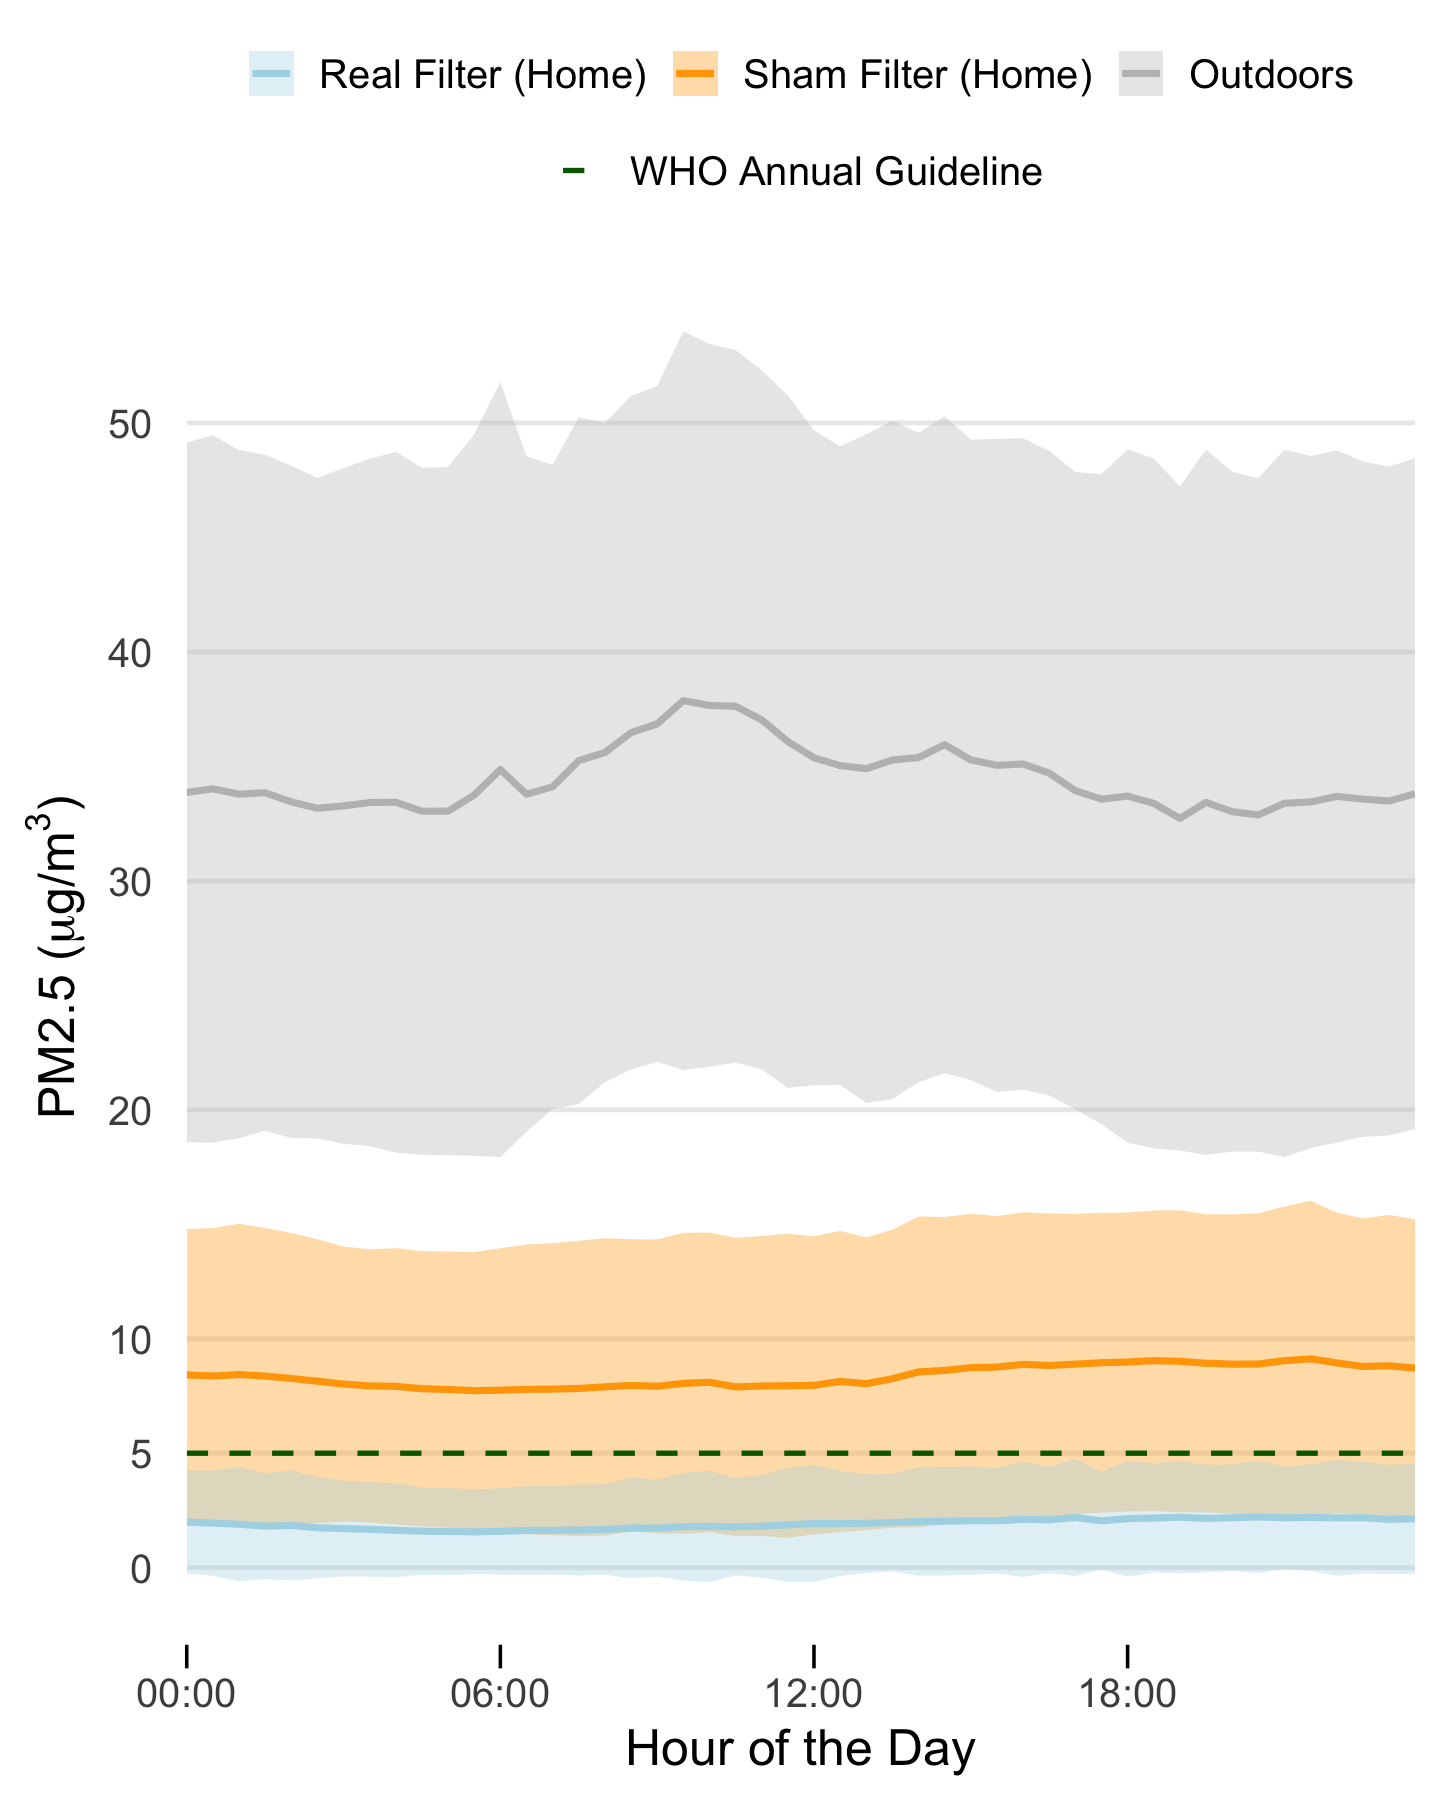

In [47]:
dimension <- plot_dimension(is_vertical = TRUE)

p <- ggplot(data_for_hourly_graph, aes(
  x = hour_minute,
  y = mean,
  color = treatment_for_plot,
  group = interaction(type_id, treatment_for_plot),
  fill = treatment_for_plot
)) +
  geom_ribbon(aes(ymin = mean - sd, ymax = mean + sd), alpha = 0.35, color = NA) +
  geom_line(size = 2) +
  geom_hline(
    aes(yintercept = WHO_PM25_GUIDELINE_VALUE, linetype = "WHO Annual Guideline"),
    size = 1.5,
    color = "darkgreen",
    alpha  =1
  ) +
  scale_linetype_manual(
    name = NULL,
    values = c("WHO Annual Guideline" = "dashed")
  )  +
  scale_x_datetime(
    date_labels = "%H:%M",
    breaks = seq(
      from = min(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      to = max(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      by = "6 hours"
    ),
    limits = c(
      min(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      max(data_for_hourly_graph$hour_minute, na.rm = TRUE)
    ),
    expand = c(0, 0)
  ) + scale_color_manual(
    values = TREATMENT_FILL_VALUES,
    labels = TREATMENT_LABELS_2,
    na.value = "gray"
  ) +
  scale_fill_manual(
    values = TREATMENT_FILL_VALUES,
    labels = TREATMENT_LABELS_2,
    na.value = "gray"
  ) +
  scale_y_continuous(
    breaks = sort(unique(c(
    seq(0, max(c(data_for_hourly_graph$mean + data_for_hourly_graph$sd, WHO_PM25_GUIDELINE_VALUE), na.rm = TRUE), by = 10),
    WHO_PM25_GUIDELINE_VALUE
    )))
  ) +
  labs(
    x = "Hour of the Day",
    y = expression("PM2.5 (" * mu * "g/m"^3 * ")"),
    color = NULL,
    fill = NULL
  ) +
  guides(
    color = guide_legend(order = 1, nrow = 1, reverse = TRUE),
    fill = guide_legend(order = 1, nrow = 1, reverse = TRUE),
    linetype = guide_legend(order = 2, ncol = 1)
  ) +
  theme_minimal(base_size = 30) +
  theme(
    axis.ticks.x = element_line(color = "black", size = 1),
    axis.ticks.length = unit(0.5, "cm"),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    plot.background = element_rect(fill = "transparent", color = NA),
    legend.key.size = unit(1, "cm"),
    legend.position = "top",
    legend.box = "vertical",
    legend.box.just  = "center",
    legend.spacing.x = unit(0, "cm"),
    legend.spacing.y = unit(0, "cm")
  )

dir.create(file.path("../visualization"), showWarnings = FALSE, recursive = TRUE)
options(repr.plot.width = dimension$width, repr.plot.height = dimension$height)

ggsave(
    filename = file.path("../visualization", 
        paste0(
            "pm25_hourly.pdf"
        )),
    plot = p,
    width = dimension$width,
    height = dimension$height,
    dpi = 300
)

p

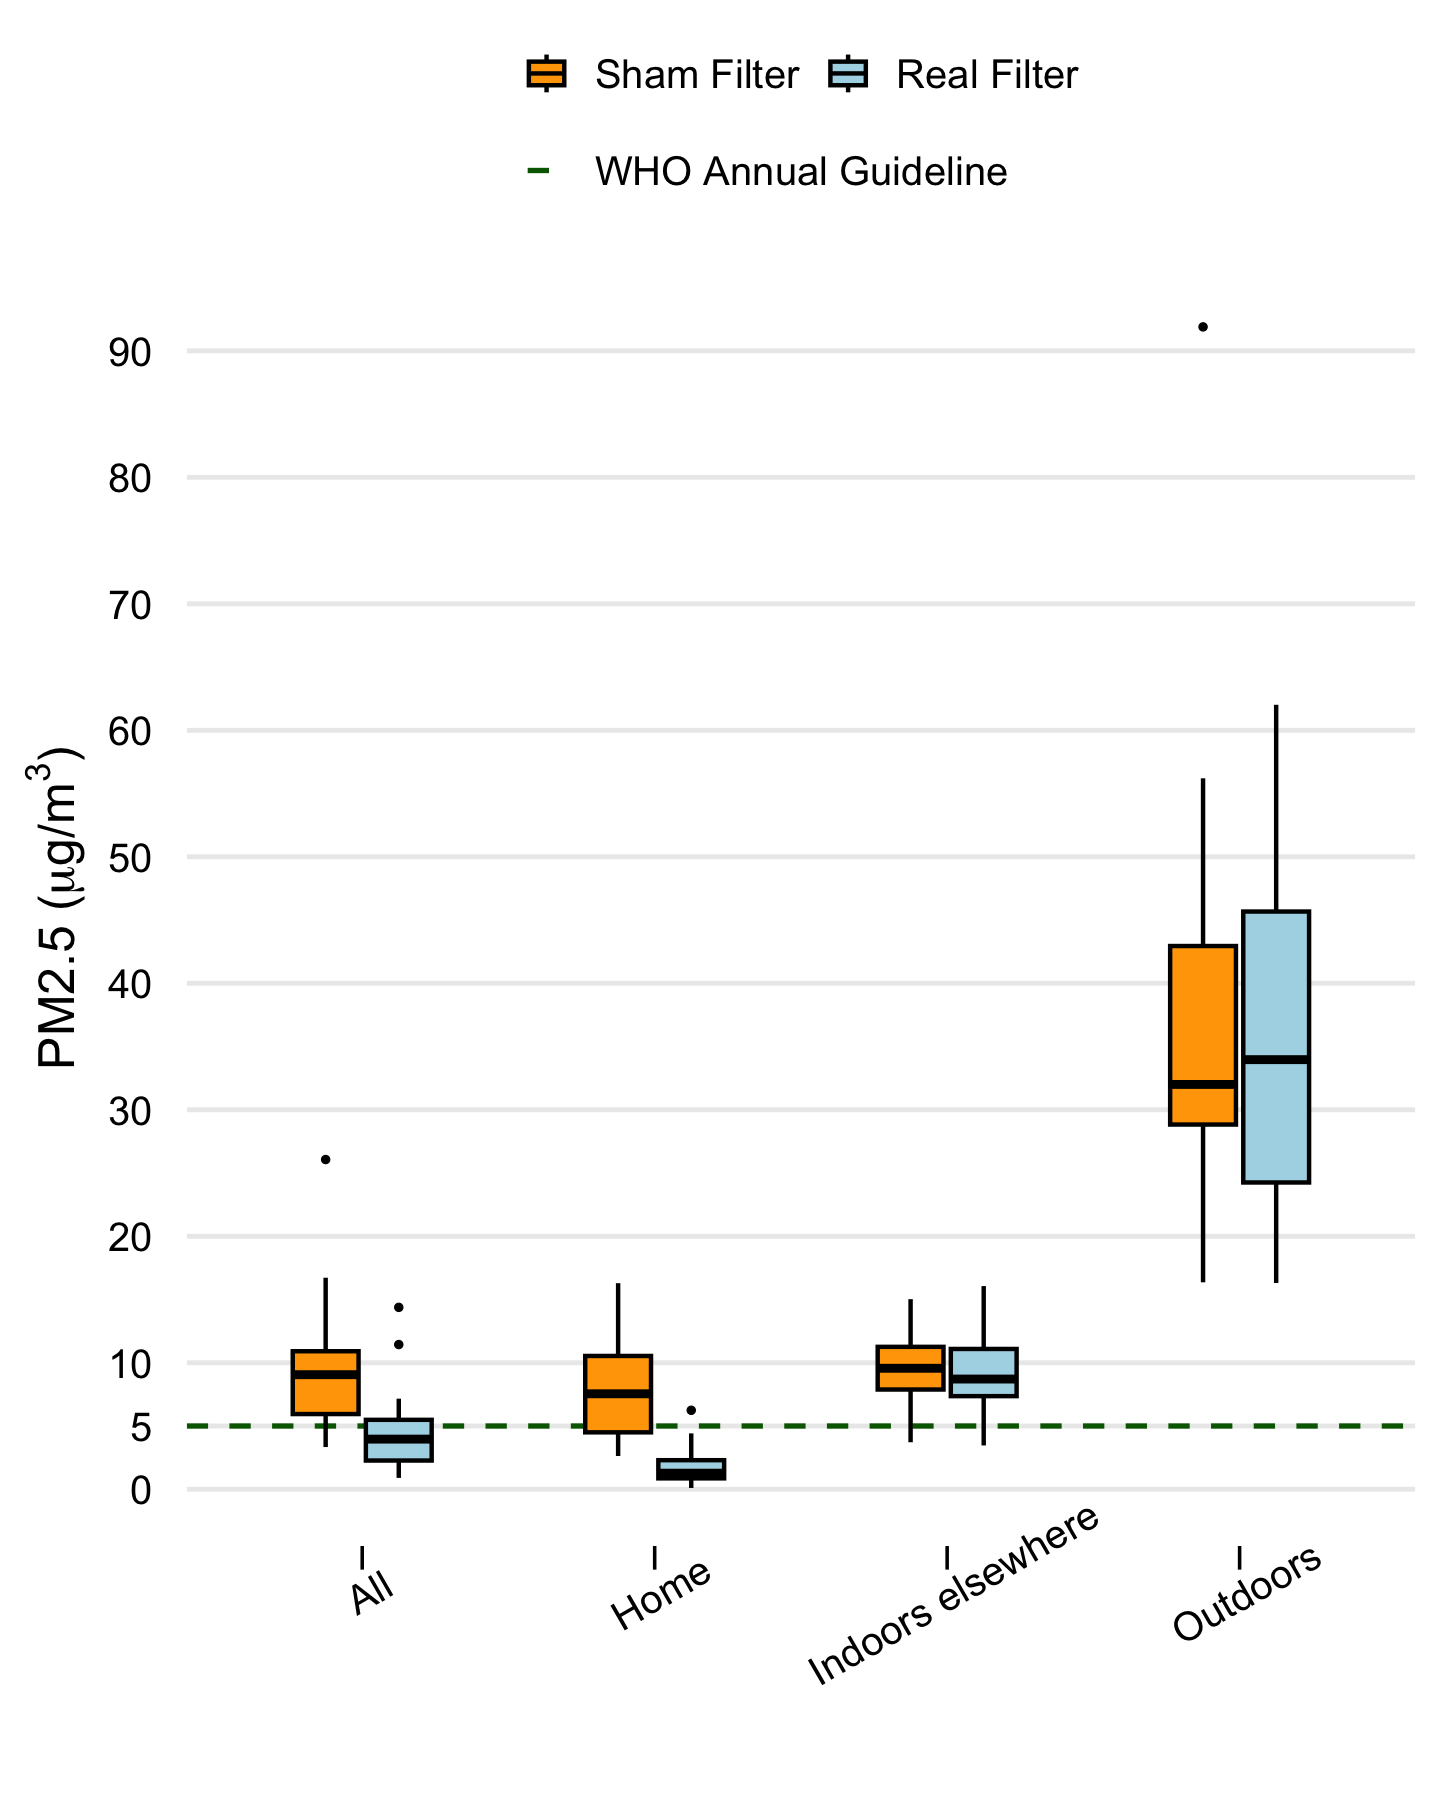

In [48]:
plot_pm25_boxplot <- function(data, is_vertical, is_black_bg) {
    dimension <- plot_dimension(is_vertical)

    # Set theme colors based on background
    point_color <- if (is_black_bg) "white" else "black"
    errorbar_color <- point_color
    hline_color <- point_color
    text_color <- point_color
    grid_color <- if (is_black_bg) "gray30" else NULL
    bg_fill <- if (is_black_bg) "black" else "transparent"
    who_line_color <- if (is_black_bg) "lightgreen" else "darkgreen"

    if (!is_vertical){
        data$type_label <- factor(data$type_label, levels = rev(unique(data$type_label)))
    }

    p <- ggplot(data, aes(x = type_label, y = .data[["pm25"]], fill = treatment)) +
        geom_hline(
            aes(yintercept = WHO_PM25_GUIDELINE_VALUE, linetype = "WHO Annual Guideline"),
            size = 1.5,
            color = "darkgreen"
        ) +
        geom_boxplot(
            width = 0.5,
            color = errorbar_color,
            size = 1.25,
            outlier.size = 2,
            position = position_dodge2(preserve = "single")
        ) 

    if (!is_vertical) {
        p <- p + 
            coord_flip() 
    }

    p <- p + scale_fill_manual(
            values = TREATMENT_FILL_VALUES,
            labels = TREATMENT_LABELS,
        ) +
        scale_y_continuous(
            breaks = sort(unique(c(
            seq(0, max(c(data$pm25, WHO_PM25_GUIDELINE_VALUE), na.rm = TRUE), by = 10),
            WHO_PM25_GUIDELINE_VALUE
            )))
        ) +
        scale_linetype_manual(
            name = NULL,
            values = c("WHO Annual Guideline" = "dashed")
        ) +
        labs(
            x = NULL,
            y = expression("PM2.5 (" * mu * "g/m"^3 * ")"),
            fill = NULL
        ) +
        guides(
            fill = guide_legend(order = 1, nrow = if (is_vertical) 1 else 1, reverse = if (is_vertical) FALSE else TRUE),
            linetype = guide_legend(order = 2, ncol = 1)
        ) +
        THEME_MINIMAL +
        theme(
            panel.grid.minor = element_blank(),
            panel.grid.major.x = if (is_vertical) element_blank() else element_line(color = grid_color),
            panel.grid.major.y = if (!is_vertical) element_blank() else element_line(color = grid_color),
            plot.background = element_rect(fill = bg_fill, color = NA),
            panel.grid.major = element_line(color = grid_color),
            axis.text = element_text(color = text_color),
            axis.title = element_text(color = text_color),
            legend.text = element_text(color = text_color),
            legend.title = element_text(color = text_color),
            legend.key.size = unit(1, "cm"),
            legend.position = "top",
            legend.box = if (is_vertical) "vertical" else "horizontal",
            legend.spacing.x = unit(0, "cm"),
            legend.spacing.y = unit(0, "cm"),
            legend.box.just  = "left",
            axis.text.x = element_text(angle = if (is_vertical) 30 else NULL, hjust = 0.5)
        )

    dir.create(file.path("../visualization"), showWarnings = FALSE, recursive = TRUE)

    ggsave(
        filename = file.path("../visualization", 
            paste0(
                "pm25_exposure_dist",
                if (is_vertical) "_vertical" else "_horizontal",
                if (is_black_bg) "_black_bg" else "_transparent_bg",
                ".pdf"
            )),
        plot = p,
        width = dimension$width,
        height = dimension$height,
        dpi = 300
    )

    options(repr.plot.width = dimension$width, repr.plot.height = dimension$height)

    return(p)
}
     
plot_pm25_boxplot(
    exposure_summary_each_participant |> 
        mutate(type_label = LOCATION_TYPE_LABELS_LATEX[type_id]),
    is_vertical = TRUE, 
    is_black_bg = FALSE)